In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import holidays
import numpy as np

pd.set_option('display.max_columns', None)

In [ ]:
# Filter documents under "data/bronze/" directory that contain "Agrupados por ocorrência"
docs = sorted(glob.glob("../data/bronze/*Agrupados por ocorrência*.parquet"))


In [3]:
docs

['../data/bronze/2017_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2018_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2019_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2020_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2021_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2022_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2023_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2024_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2025_Agrupados por ocorrência.csv.gz',
 '../data/bronze/2026_Agrupados por ocorrência.csv.gz']

In [4]:
# Load all docs into a single DataFrame
df_list = []
for doc in docs:
    df = pd.read_parquet(doc)
    df_list.append(df)

all_data = pd.concat(df_list, ignore_index=True)

In [5]:
# municipios = [
#  'GRAVATA',
#  'POMBOS',
#  'RECIFE',
#  'MORENO',
#  'CARUARU',
#  'VITORIA DE SANTO ANTAO',
#  'BEZERROS',
#  'JABOATAO DOS GUARARAPES',
#  'SAIRE',
#  'CHA GRANDE',
#  'CAMARAGIBE',
#  'NAZARE DA MATA']

br101_raw = all_data[(all_data["br"] == 101)]


br101_raw.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
2,69.0,2017-01-01,domingo,04:40:00,BA,101,65,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,5,1,1,1,2,0,2,2,"-11,9618","-38,0953",SPRF-BA,DEL01-BA,UOP04-DEL01-BA
10,146.0,2017-01-01,domingo,12:10:00,BA,101,"23,7",RIO REAL,Falta de Atenção à Condução,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Sol,Simples,Reta,Não,7,1,2,1,2,4,3,7,"-50,19940894","-94,49999571",SPRF-SE,DEL02-SE,UOP03-DEL02-SE
15,192.0,2017-01-01,domingo,15:55:00,PE,101,"62,8",RECIFE,Falta de Atenção do Pedestre,Atropelamento de Pedestre,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Sim,3,0,0,1,1,1,1,2,"-8,007427","-34,937846",SPRF-PE,DEL01-PE,UOP02-DEL01-PE
17,217.0,2017-01-01,domingo,18:10:00,ES,101,"301,6",VIANA,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Reta,Sim,11,0,2,0,8,1,2,9,"-20,37093446","-40,44363284",SPRF-ES,DEL01-ES,UOP01-DEL01-ES
20,237.0,2017-01-01,domingo,17:15:00,AL,101,190,JUNQUEIRO,Fenômenos da Natureza,Incêndio,Sem Vítimas,Anoitecer,Crescente,Nublado,Simples,Reta,Sim,1,0,0,0,1,0,0,1,"-9,9171","-36,4736",SPRF-AL,DEL02-AL,UOP02-DEL02-AL


In [6]:
br101 = br101_raw.copy()

br101

br101['id'] = br101['id'].astype(int)
br101['km'] = br101['km'].str.replace(',', '.').astype(float)
br101['latitude'] = br101['latitude'].str.replace(',', '.').astype(float)
br101['longitude'] = br101['longitude'].str.replace(',', '.').astype(float)
# create timestamp from data_inversa (yyyy-mm-dd) and horario (hh:mm:ss)
br101['timestamp'] = pd.to_datetime(br101['data_inversa'] + ' ' + br101['horario'])

br101["quarter"] = br101["timestamp"].dt.quarter
br101["year"] = br101["timestamp"].dt.year
br101["month"] = br101["timestamp"].dt.month

# tracado_via has the following ";" separated unique values:

# ['Reta',
#  'Aclive',
#  'Declive',
#  'Interseção de Vias',
#  'Curva',
#  'Retorno Regulamentado',
#  'Viaduto',
#  'Túnel',
#  'Em Obras',
#  'Rotatória',
#  'Ponte',
#  'Desvio Temporário']

# should be broken into the following binary columns:
# - aclive/declive
# - reta/curva
# - interseção de vias
# - retorno regulamentado
# - viaduto
# - túnel
# - em obras
# - rotatória
# - ponte
# - desvio temporário

# TODO: clean away spurious, out of road data
# try to extract enrichment data (speed limit, road curvature/profile) from https://servicos.dnit.gov.br/dnitcloud/index.php/s/oTpPRmYs5AAdiNr?path=%2FSNV%20Bases%20Geom%C3%A9tricas%20(2013-Atual)%20(SHP)


tracado = br101["tracado_via"].fillna("")

# 1 = Aclive, 0 = Declive, <NA> = neither found
br101["aclivedeclive"] = tracado.apply(
    lambda x: "Aclive" if "Aclive" in x else "Declive" if "Declive" in x else "<NA>"
)

# 1 = Reta, 0 = Curva, <NA> = neither found
br101["reta_curva"] = tracado.apply(
    lambda x: "Reta" if "Reta" in x else "Curva" if "Curva" in x else "<NA>"
)

# 1 = has "Interseção de Vias", 0 = does not have
br101["intersecao_de_vias"] = tracado.str.contains("Interseção de Vias").astype(int)
br101['retorno_regulamentado'] = br101['tracado_via'].apply(lambda x: 'Retorno Regulamentado' in x)
br101['viaduto'] = br101['tracado_via'].apply(lambda x: 'Viaduto' in x)
br101['tunel'] = br101['tracado_via'].apply(lambda x: 'Túnel' in x)
br101['em_obras'] = br101['tracado_via'].apply(lambda x: 'Em Obras' in x)
br101['rotatoria'] = br101['tracado_via'].apply(lambda x: 'Rotatória' in x)
br101['ponte'] = br101['tracado_via'].apply(lambda x: 'Ponte' in x)
br101['desvio_temporario'] = br101['tracado_via'].apply(lambda x: 'Desvio Temporário' in x)

# create a base list h = holidays.HolidayBase() of all holidays in Brazil PE from 2000 to 2030
h = holidays.HolidayBase()
for year in range(2000, 2031):
    h.append(holidays.Brazil(years=year))


# Add holiday distance features + cyclical time-of-year feature
holiday_index = pd.DatetimeIndex(sorted(pd.to_datetime(list(h.keys()))))
ts = br101["timestamp"]

next_pos = holiday_index.searchsorted(ts.dt.normalize(), side="left")
prev_pos = holiday_index.searchsorted(ts.dt.normalize(), side="right") - 1

next_holiday = pd.Series(pd.NaT, index=br101.index, dtype="datetime64[ns]")
prev_holiday = pd.Series(pd.NaT, index=br101.index, dtype="datetime64[ns]")

valid_next = next_pos < len(holiday_index)
valid_prev = prev_pos >= 0

next_holiday.loc[valid_next] = holiday_index[next_pos[valid_next]].values
prev_holiday.loc[valid_prev] = holiday_index[prev_pos[valid_prev]].values

br101["hours_to_next_holiday"] = (next_holiday - ts).dt.total_seconds() / 3600
br101["hours_from_last_holiday"] = (ts - prev_holiday).dt.total_seconds() / 3600

# if accident happened on a holiday date, both distances are zero
is_holiday = ts.dt.normalize().isin(holiday_index)
br101.loc[is_holiday, "hours_to_next_holiday"] = 0.0
br101.loc[is_holiday, "hours_from_last_holiday"] = 0.0

# cosine of time of year (continuous, includes hour/min/sec)
days_in_year = 365 + ts.dt.is_leap_year.astype(int)
year_fraction = (
    (ts.dt.dayofyear - 1)
    + ts.dt.hour / 24
    + ts.dt.minute / 1440
    + ts.dt.second / 86400
) / days_in_year

br101["cos_time_of_year"] = np.cos(2 * np.pi * year_fraction)


In [7]:
br101

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,timestamp,quarter,year,month,aclivedeclive,reta_curva,intersecao_de_vias,retorno_regulamentado,viaduto,tunel,em_obras,rotatoria,ponte,desvio_temporario,hours_to_next_holiday,hours_from_last_holiday,cos_time_of_year
2,69,2017-01-01,domingo,04:40:00,BA,101,65.0,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,5,1,1,1,2,0,2,2,-11.961800,-38.095300,SPRF-BA,DEL01-BA,UOP04-DEL01-BA,2017-01-01 04:40:00,1,2017,1,<NA>,Curva,0,False,False,False,False,False,False,False,0.000000,0.000000,0.999994
10,146,2017-01-01,domingo,12:10:00,BA,101,23.7,RIO REAL,Falta de Atenção à Condução,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Sol,Simples,Reta,Não,7,1,2,1,2,4,3,7,-50.199409,-94.499996,SPRF-SE,DEL02-SE,UOP03-DEL02-SE,2017-01-01 12:10:00,1,2017,1,<NA>,Reta,0,False,False,False,False,False,False,False,0.000000,0.000000,0.999962
15,192,2017-01-01,domingo,15:55:00,PE,101,62.8,RECIFE,Falta de Atenção do Pedestre,Atropelamento de Pedestre,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Sim,3,0,0,1,1,1,1,2,-8.007427,-34.937846,SPRF-PE,DEL01-PE,UOP02-DEL01-PE,2017-01-01 15:55:00,1,2017,1,<NA>,Reta,0,False,False,False,False,False,False,False,0.000000,0.000000,0.999935
17,217,2017-01-01,domingo,18:10:00,ES,101,301.6,VIANA,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Reta,Sim,11,0,2,0,8,1,2,9,-20.370934,-40.443633,SPRF-ES,DEL01-ES,UOP01-DEL01-ES,2017-01-01 18:10:00,1,2017,1,<NA>,Reta,0,False,False,False,False,False,False,False,0.000000,0.000000,0.999915
20,237,2017-01-01,domingo,17:15:00,AL,101,190.0,JUNQUEIRO,Fenômenos da Natureza,Incêndio,Sem Vítimas,Anoitecer,Crescente,Nublado,Simples,Reta,Sim,1,0,0,0,1,0,0,1,-9.917100,-36.473600,SPRF-AL,DEL02-AL,UOP02-DEL02-AL,2017-01-01 17:15:00,1,2017,1,<NA>,Reta,0,False,False,False,False,False,False,False,0.000000,0.000000,0.999923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638456,754568,2026-01-24,sábado,16:00:00,RJ,101,548.2,PARATY,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Chuva,Simples,Reta,Não,2,0,1,1,0,0,2,1,-23.045075,-44.648397,SPRF-RJ,DEL03-RJ,UOP04-DEL03-RJ,2026-01-24 16:00:00,1,2026,1,<NA>,Reta,0,False,False,False,False,False,False,False,1640.000000,568.000000,0.918153
638460,754674,2026-01-27,terça-feira,06:10:00,RJ,101,491.8,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Curva,Não,6,0,0,1,5,0,1,2,-22.928042,-44.362793,SPRF-RJ,DEL03-RJ,UOP03-DEL03-RJ,2026-01-27 06:10:00,1,2026,1,<NA>,Curva,0,False,False,False,False,False,False,False,1577.833333,630.166667,0.899579
638461,754677,2026-01-10,sábado,08:10:00,RJ,101,472.0,ANGRA DOS REIS,Conversão proibida,Colisão transversal,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Reta,Não,2,0,0,1,1,0,1,2,-22.990002,-44.239197,SPRF-RJ,DEL03-RJ,UOP03-DEL03-RJ,2026-01-10 08:10:00,1,2026,1,<NA>,Reta,0,False,False,False,False,False,False,False,1983.833333,224.166667,0.987102
638465,754975,2026-01-24,sábado,07:30:00,RJ,101,310.0,SAO GONCALO,Mal súbito do condutor,Saída de leito carroçável,Com Vítimas Feridas,Amanhecer,Crescente,Chuva,Dupla,Reta,Sim,1,0,1,0,0,0,1,1,-22.834659,-43.096431,SPRF-RJ,DEL02-RJ,UOP02-DEL02-RJ,2026-01-24 07:30:00,1,2026,1,<NA>,Reta,0,False,False,False,False,False,False,False,1648.500000,559.500000,0.920552


In [ ]:
# acidentes por semana por município
weekly_municipio = (
    br101.assign(week=br101["timestamp"].dt.to_period("W").dt.start_time)
    .groupby(["week", "uf", "municipio"])
    .size()
    .reset_index(name="n_acidentes")
)

# para manter o gráfico legível, usa os municípios com mais acidentes no total
top_n = 20
top_municipios = (
    weekly_municipio.groupby(["uf", "municipio"])["n_acidentes"]
    .sum()
    .nlargest(top_n)
    .index
)

print(list(top_municipios))

# filtra usando o par (uf, municipio), já que top_municipios é MultiIndex de tuplas
weekly_top = weekly_municipio[
    weekly_municipio.set_index(["uf", "municipio"]).index.isin(top_municipios)
].copy()

# rótulo único para evitar colisão de nomes de município entre UFs
weekly_top["municipio_label"] = weekly_top["uf"] + " - " + weekly_top["municipio"]

heatmap_data = (
    weekly_top.pivot_table(
        index="week",
        columns="municipio_label",
        values="n_acidentes",
        aggfunc="sum",
        fill_value=0,
    )
)

plt.figure(figsize=(18, 8))
sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    cbar_kws={"label": "Número de acidentes por semana"},
)
plt.title(f"Distribuição semanal de acidentes por município (Top {top_n} em BR-101)")
plt.xlabel("Semana")
plt.ylabel("Município")
plt.tight_layout()
plt.show()

MultiIndex([('SC',              'SAO JOSE'),
            ('ES',                 'SERRA'),
            ('SC',               'PALHOCA'),
            ('PE',                'RECIFE'),
            ('SC',                'ITAJAI'),
            ('SC',    'BALNEARIO CAMBORIU'),
            ('RJ', 'CAMPOS DOS GOYTACAZES'),
            ('SC',             'JOINVILLE'),
            ('ES',              'LINHARES'),
            ('SC',               'BIGUACU'),
            ('RJ',        'ANGRA DOS REIS'),
            ('RJ',           'SAO GONCALO'),
            ('RN',                 'NATAL'),
            ('ES',             'CARIACICA'),
            ('SC',               'ITAPEMA'),
            ('SP',               'UBATUBA'),
            ('SC',               'TUBARAO'),
            ('RN',            'PARNAMIRIM'),
            ('PE',              'IGARASSU'),
            ('RJ',               'NITEROI')],
           names=['uf', 'municipio'])


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1800x800 with 0 Axes>

###




### Features to add
- Hours before or since last holiday
- Duration of last holiday
- Duration of next holiday
- Cosine of time of year

- Climate (of two stations at each point):
    - Windspeed: mean, median, max, min, std, delta, acceleration
    - Rain: mean, median, max, min, std, delta, acceleration

In [72]:
br101.info()

<class 'pandas.DataFrame'>
Index: 4402 entries, 25 to 638265
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      4402 non-null   int64         
 1   data_inversa            4402 non-null   str           
 2   dia_semana              4402 non-null   str           
 3   horario                 4402 non-null   str           
 4   uf                      4402 non-null   str           
 5   br                      4402 non-null   int64         
 6   km                      4402 non-null   float64       
 7   municipio               4402 non-null   str           
 8   causa_acidente          4402 non-null   str           
 9   tipo_acidente           4402 non-null   str           
 10  classificacao_acidente  4402 non-null   str           
 11  fase_dia                4402 non-null   str           
 12  sentido_via             4402 non-null   str           
 13  c

count   mean  std    min    25%    50%    75%    max
uf km                                                         
AL 0.1      1.0    0.1  NaN    0.1    0.1    0.1    0.1    0.1
   0.2      2.0    0.2  0.0    0.2    0.2    0.2    0.2    0.2
   0.5      1.0    0.5  NaN    0.5    0.5    0.5    0.5    0.5
   0.8      1.0    0.8  NaN    0.8    0.8    0.8    0.8    0.8
   1.0      1.0    1.0  NaN    1.0    1.0    1.0    1.0    1.0
...         ...    ...  ...    ...    ...    ...    ...    ...
SP 393.0    1.0  393.0  NaN  393.0  393.0  393.0  393.0  393.0
   395.0    1.0  395.0  NaN  395.0  395.0  395.0  395.0  395.0
   396.0    1.0  396.0  NaN  396.0  396.0  396.0  396.0  396.0
   401.0    1.0  401.0  NaN  401.0  401.0  401.0  401.0  401.0
   402.0    1.0  402.0  NaN  402.0  402.0  402.0  402.0  402.0

[17835 rows x 8 columns]

count   mean  std    min    25%    50%    75%    max
uf km                                                         
AL 0.1      1.0    0.1  NaN    0.1    0.1    0.1    0.1    0.1
   0.2      2.0    0.2  0.0    0.2    0.2    0.2    0.2    0.2
   0.5      1.0    0.5  NaN    0.5    0.5    0.5    0.5    0.5
   0.8      1.0    0.8  NaN    0.8    0.8    0.8    0.8    0.8
   1.0      1.0    1.0  NaN    1.0    1.0    1.0    1.0    1.0
...         ...    ...  ...    ...    ...    ...    ...    ...
SP 393.0    1.0  393.0  NaN  393.0  393.0  393.0  393.0  393.0
   395.0    1.0  395.0  NaN  395.0  395.0  395.0  395.0  395.0
   396.0    1.0  396.0  NaN  396.0  396.0  396.0  396.0  396.0
   401.0    1.0  401.0  NaN  401.0  401.0  401.0  401.0  401.0
   402.0    1.0  402.0  NaN  402.0  402.0  402.0  402.0  402.0

[17835 rows x 8 columns]

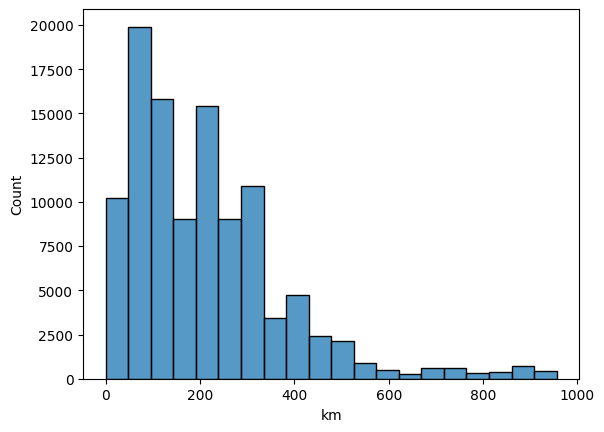

In [127]:
br101.describe()

count    4402.000000
mean       58.541776
std        43.567558
min         5.100000
25%        13.000000
50%        56.100000
75%        94.875000
max       180.000000
Name: km, dtype: float64

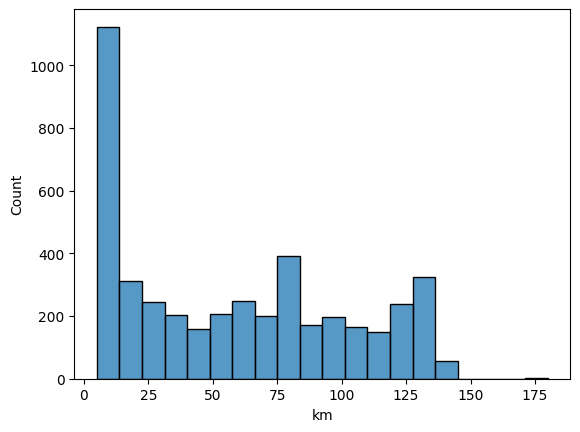

In [76]:
# show distribution of km

sns.histplot(br101["km"], bins=20)

br101["km"].describe()

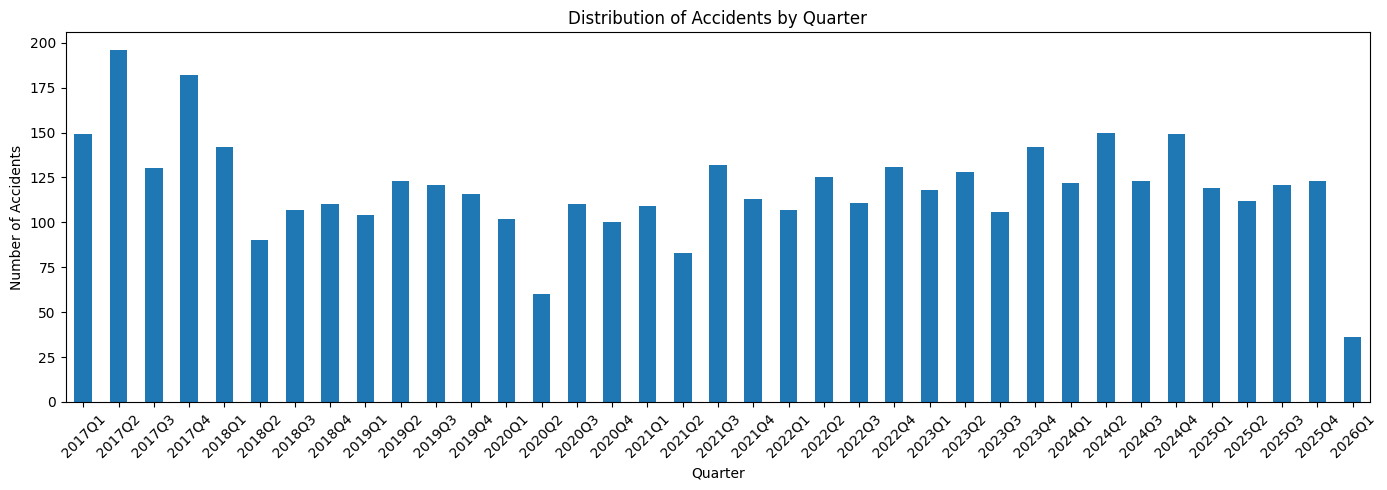

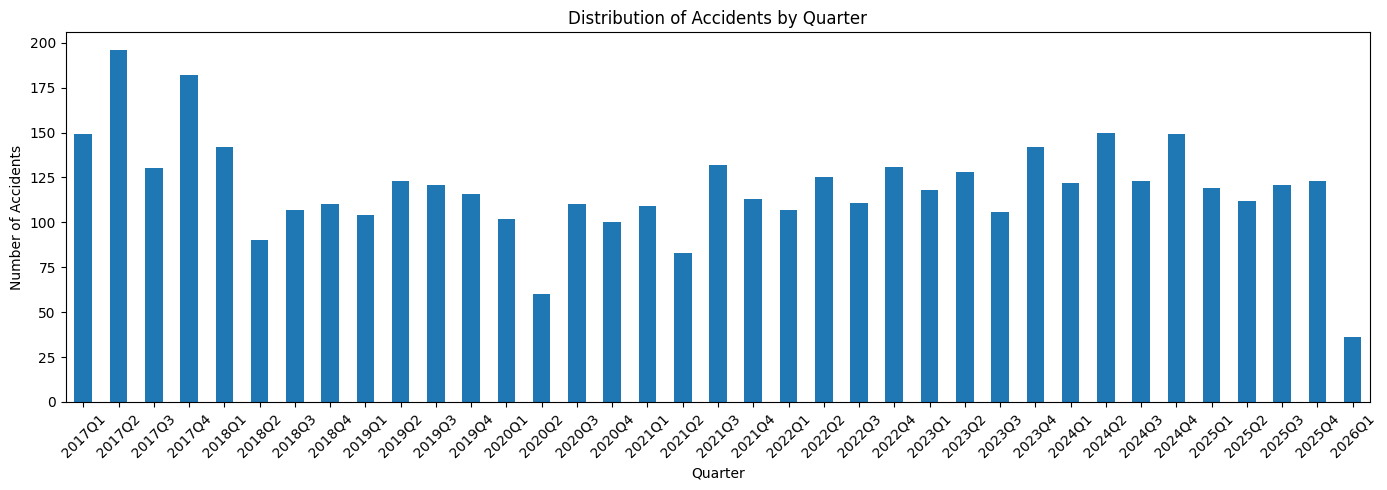

<Figure size 1000x600 with 0 Axes>

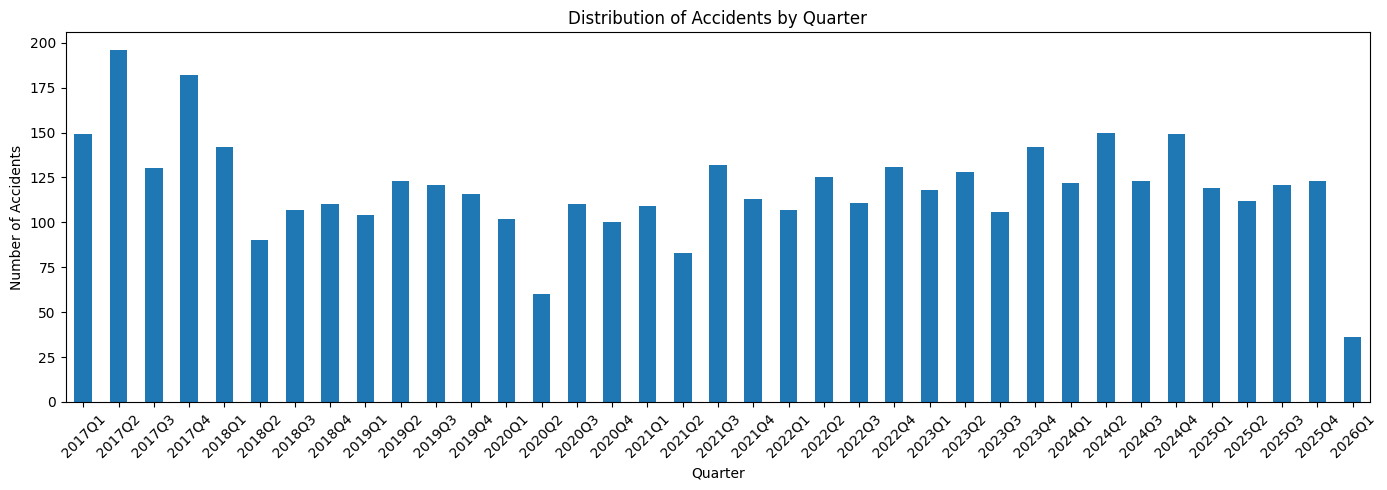

<Figure size 1000x600 with 0 Axes>

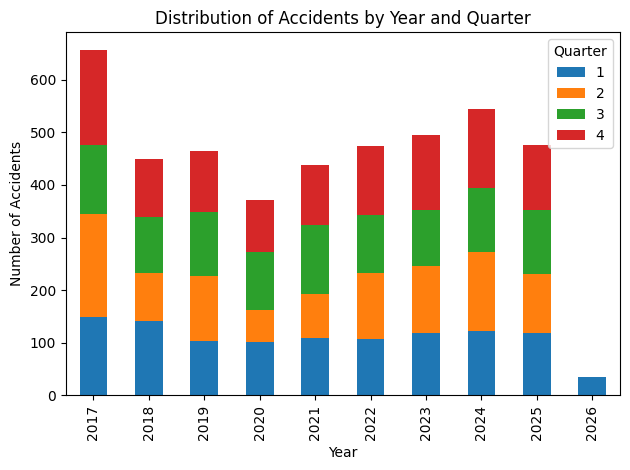

In [79]:
# show distribution of year and quarters (timestamp binned by quarter)

quarter_counts = br101["timestamp"].dt.to_period("Q").value_counts().sort_index()

plt.figure(figsize=(14, 5))
quarter_counts.plot(kind="bar")
plt.title("Distribution of Accidents by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

quarter_summary = (
    br101.groupby([br101["timestamp"].dt.year, br101["timestamp"].dt.quarter])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 6))
quarter_summary.plot(kind="bar", stacked=True)
plt.title("Distribution of Accidents by Year and Quarter")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.legend(title="Quarter")
plt.tight_layout()
plt.show()


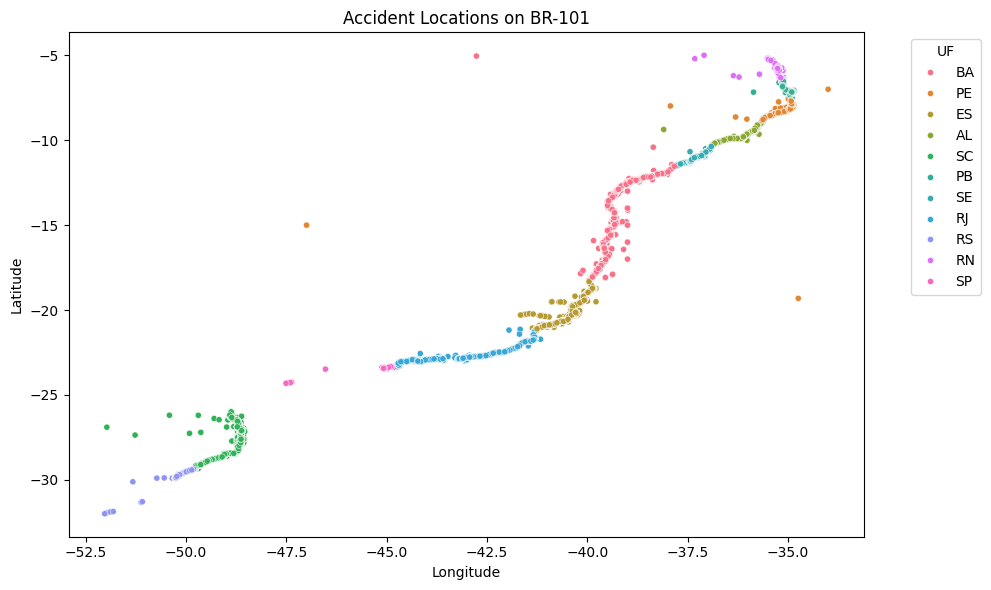

In [133]:
# plot the distribution of accidents by month
month_counts = br101["timestamp"].dt.month.value_counts().sort_index()
plt.figure(figsize=(10, 6))
month_counts.plot(kind="bar")
plt.title("Distribution of Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

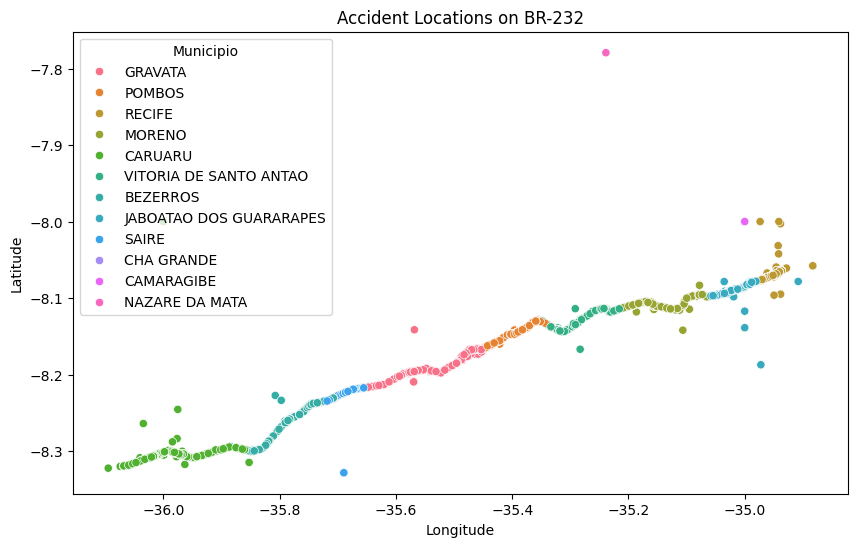

In [41]:
# plot the latitude and longitude of the accidents
plt.figure(figsize=(10, 6))
sns.scatterplot(x="longitude", y="latitude", data=br101, hue="uf")
plt.title("Accident Locations on BR-101")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Municipio")
plt.show()

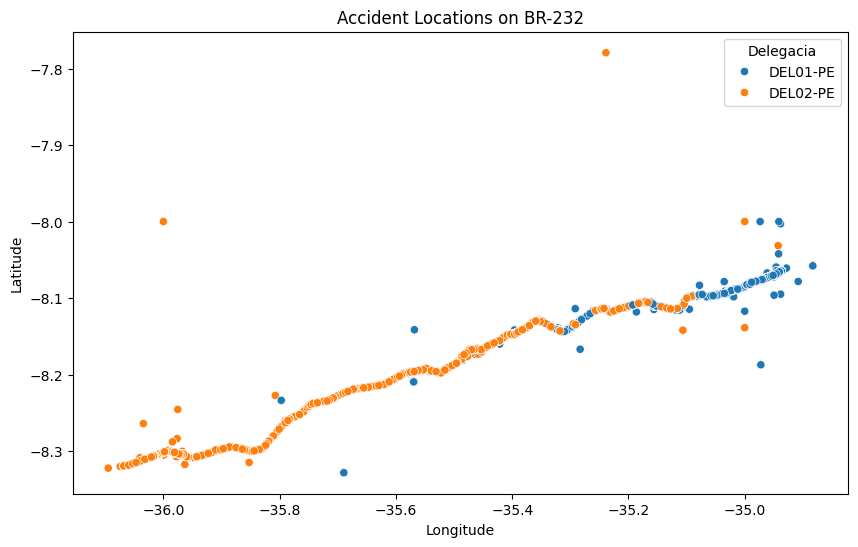

In [46]:
# plot the latitude and longitude of the accidents
plt.figure(figsize=(10, 6))
sns.scatterplot(x="longitude", y="latitude", data=br232, hue="delegacia")
plt.title("Accident Locations on BR-232")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Delegacia")
plt.show()

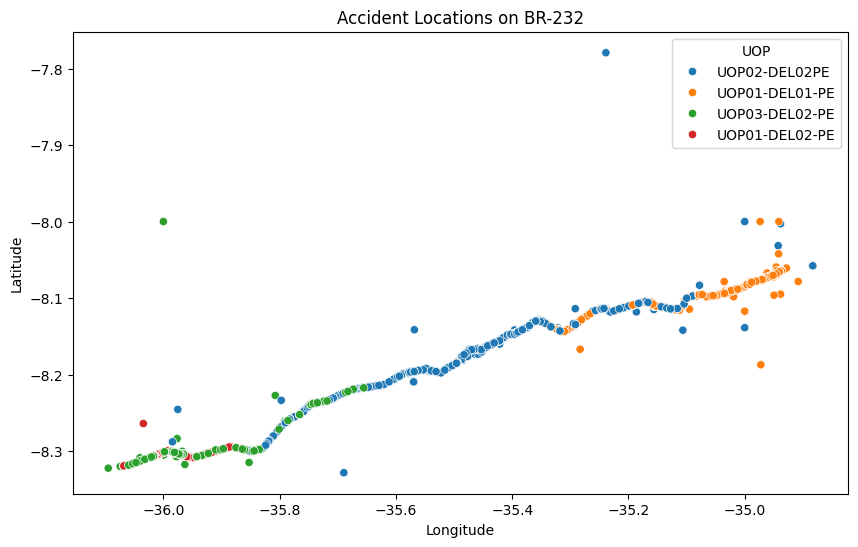

In [45]:
# plot the latitude and longitude of the accidents
plt.figure(figsize=(10, 6))
sns.scatterplot(x="longitude", y="latitude", data=br232, hue="uop")
plt.title("Accident Locations on BR-232")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="UOP")
plt.show()

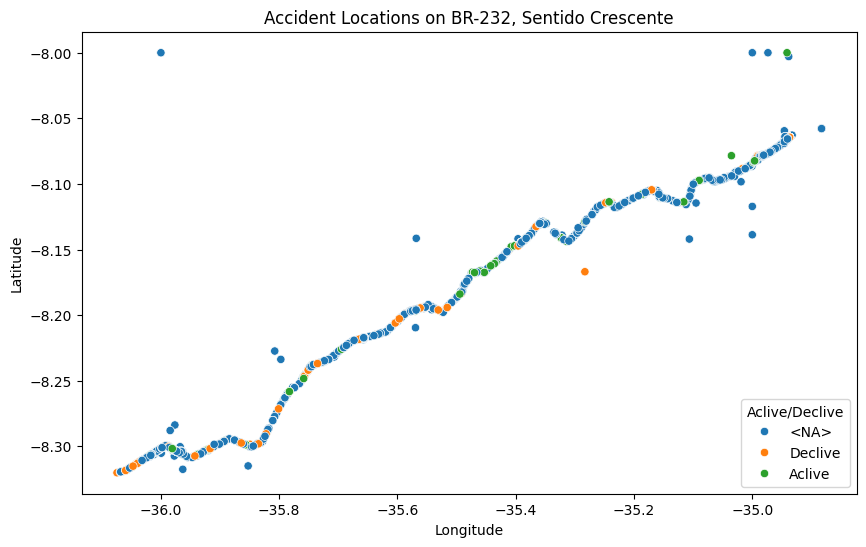

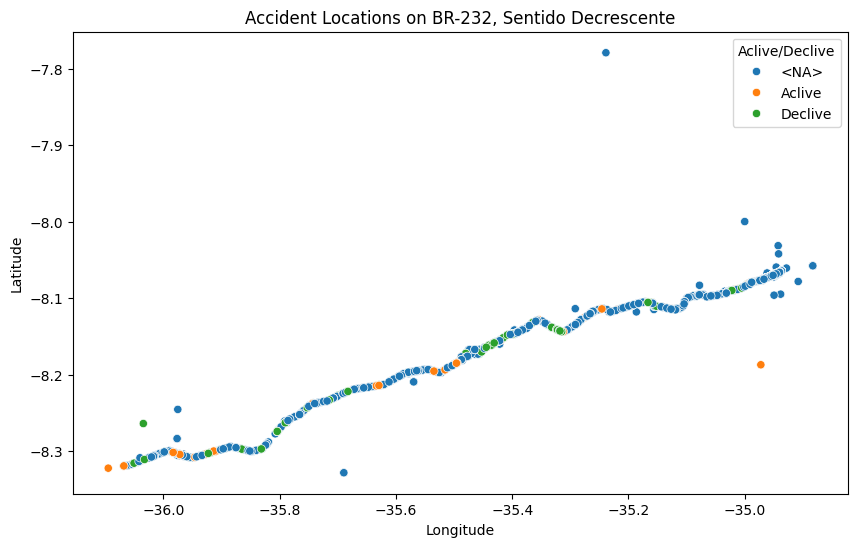

In [65]:
# plot the latitude and longitude of the accidents
plt.figure(figsize=(10, 6))
sns.scatterplot(x="longitude", y="latitude", data=br232[br232['sentido_via'] == 'Crescente'], hue="aclivedeclive")
plt.title("Accident Locations on BR-232, Sentido Crescente")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Aclive/Declive")
plt.show()

# plot the latitude and longitude of the accidents
plt.figure(figsize=(10, 6))
sns.scatterplot(x="longitude", y="latitude", data=br232[br232['sentido_via'] == 'Decrescente'], hue="aclivedeclive")
plt.title("Accident Locations on BR-232, Sentido Decrescente")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Aclive/Declive")
plt.show()

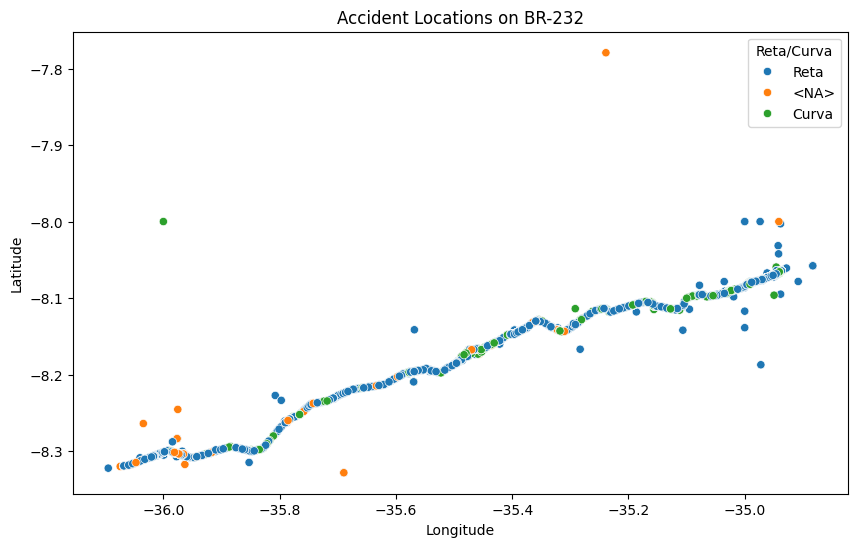

In [63]:
# plot the latitude and longitude of the accidents
plt.figure(figsize=(10, 6))
sns.scatterplot(x="longitude", y="latitude", data=br232, hue="reta_curva")
plt.title("Accident Locations on BR-232")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Reta/Curva")
plt.show()